In [1]:
# CNN_Light
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
# ================= CONFIG =================
DATA_DIR = r"C:\Users\cathe\Desktop\Programming\Projects\Python\GenerativeTerrain\preprocessed_solid"
BATCH_SIZE = 8
NUM_EPOCHS = 5
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True  # mixed precision

In [3]:
# ================= HELPERS =================
def is_air(block_id: str) -> bool:
    return str(block_id).upper() in AIR_BLOCK_NAMES

In [4]:
# ================= DATASET =================
class SolidChunkDataset(Dataset):
    def __init__(self, path):
        self.files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".pt")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x, y = torch.load(self.files[idx])
        return x.float(), y.long()  # ensure float32 for inputs

dataset = SolidChunkDataset(DATA_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

In [5]:
# ================= MODEL =================
class Simple3DCNN(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv3d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv3d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv3d(128, 1, 1)  # output logits for binary classification
        )

    def forward(self, x):
        return self.net(x)

model = Simple3DCNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

C:\Users\cathe\AppData\Local\Temp\ipykernel_32060\3599468240.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [6]:
# ================= TRAIN =================
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for x, y in tqdm(loader, desc=f"Epoch {epoch+1}"):
        x, y = x.to(DEVICE), y.to(DEVICE).unsqueeze(1).float()  # [B, 1, X, Y, Z]

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Avg Loss: {total_loss/len(loader):.4f}")

Epoch 1:   0%|          | 0/230 [00:00<?, ?it/s]C:\Users\cathe\AppData\Local\Temp\ipykernel_32060\1343985518.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x, y = torc

Epoch 1 | Avg Loss: 0.0292


Epoch 2: 100%|██████████| 230/230 [00:01<00:00, 124.29it/s]


Epoch 2 | Avg Loss: 0.0059


Epoch 3: 100%|██████████| 230/230 [00:01<00:00, 152.93it/s]


Epoch 3 | Avg Loss: 0.0046


Epoch 4: 100%|██████████| 230/230 [00:01<00:00, 154.52it/s]


Epoch 4 | Avg Loss: 0.0044


Epoch 5: 100%|██████████| 230/230 [00:01<00:00, 155.19it/s]

Epoch 5 | Avg Loss: 0.0042


In [7]:
# ================= TEST =================
x, y = dataset[0]
x, y = x.unsqueeze(0).to(DEVICE), y.unsqueeze(0).unsqueeze(1).to(DEVICE)
with torch.no_grad(), torch.cuda.amp.autocast(enabled=USE_AMP):
    logits = model(x)
    preds = (torch.sigmoid(logits) > 0.5).float()
print("Example batch | Solid ratio:", preds.mean().item())

Example batch | Solid ratio: 0.8575439453125


C:\Users\cathe\AppData\Local\Temp\ipykernel_32060\1343985518.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x, y = torch.load(self.files[idx])
C:\Users\cathe\AppData\L

In [8]:
model.eval()

Simple3DCNN(
  (net): Sequential(
    (0): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU()
    (4): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): ReLU()
    (6): Conv3d(128, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  )
)

In [9]:
# ================= LOAD EXAMPLE =================
files = [f for f in os.listdir(DATA_DIR) if f.endswith(".pt")]
x, y = torch.load(os.path.join(DATA_DIR, files[0]))
x = x.unsqueeze(0).to(DEVICE).float()  # add batch dimension
y = y.unsqueeze(0).to(DEVICE).unsqueeze(1).float()

C:\Users\cathe\AppData\Local\Temp\ipykernel_32060\3211903956.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x, y = torch.load(os.path.join(DATA_DIR, files[0]))


In [10]:
# ================= RUN PREDICTION =================
with torch.no_grad(), torch.amp.autocast(device_type='cuda', enabled=True):
    logits = model(x)
    preds = torch.sigmoid(logits)  # [B,1,X,Y,Z]

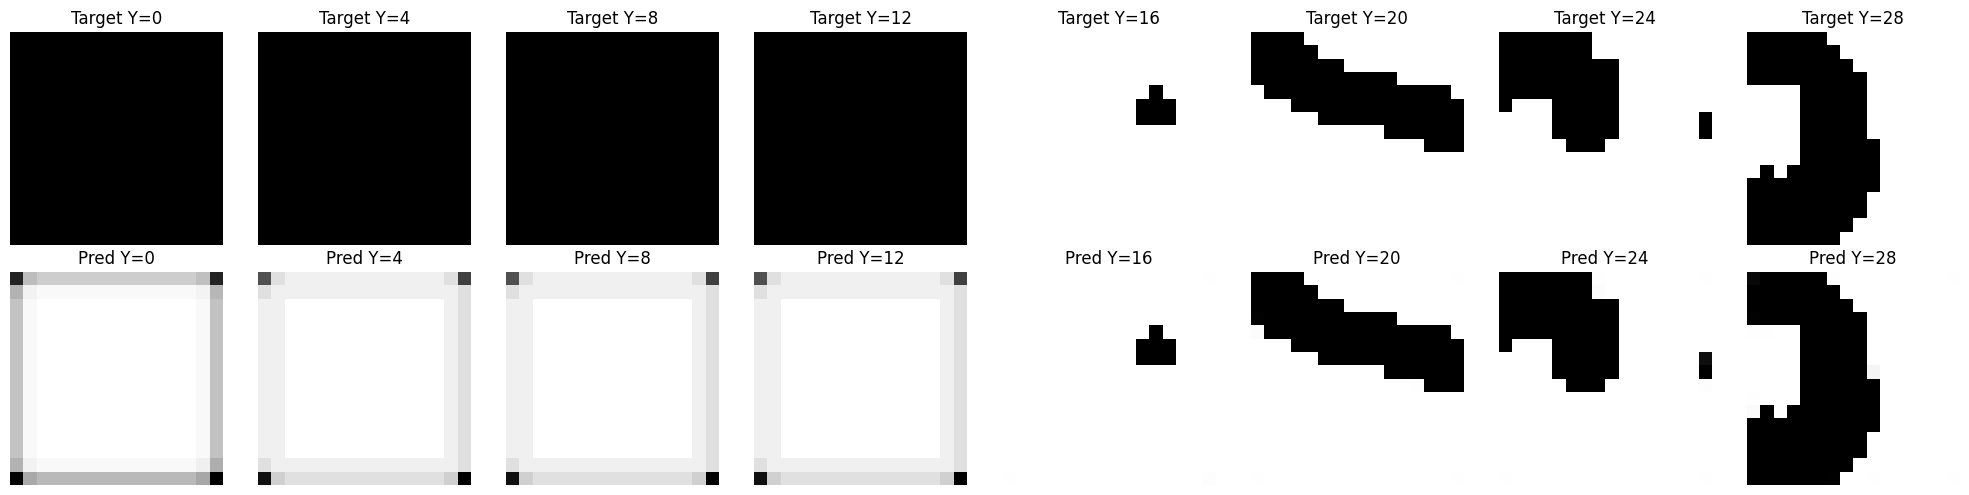

In [12]:
# ================= PLOT SLICES =================
# Choose some Y slices to inspect
import matplotlib.pyplot as plt
import numpy as np
preds_np = preds[0,0].cpu().numpy()  # [X,Y,Z]
target_np = y[0,0].cpu().numpy()

num_slices = preds_np.shape[1]
step = max(1, num_slices // 8)  # plot 8 slices max

fig, axes = plt.subplots(2, 8, figsize=(20,5))
for i, y_slice in enumerate(range(0, num_slices, step)):
    axes[0,i].imshow(target_np[:,y_slice,:], cmap='gray', origin='lower')
    axes[0,i].set_title(f"Target Y={y_slice}")
    axes[0,i].axis('off')

    axes[1,i].imshow(preds_np[:,y_slice,:], cmap='gray', origin='lower')
    axes[1,i].set_title(f"Pred Y={y_slice}")
    axes[1,i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Move model to CPU
model.cpu()
model.eval()

# Create a CPU dummy input with the right shape
dummy_input = torch.randn(1, 2, 16, 32, 16)  # adjust width/height/depth if needed

# Export to ONNX
onnx_path = r"C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\plugins_serverterrain_transformer_CNN_light.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

print(f"ONNX model saved to {onnx_path}")

ONNX model saved to C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\plugins_serverterrain_transformer_CNN_light.onnx


In [23]:
model_path = r"C:\Users\cathe\Desktop\Plugins\Server\plugins\GenerativeTerrain\terrain_transformer_CNN_light"

onnx_model = onnx.load(model_path)
onnx.checker.check_model(onnx_model)

for input_tensor in onnx_model.graph.input:
    shape = [dim.dim_value for dim in input_tensor.type.tensor_type.shape.dim]
    print(f"{input_tensor.name}: {shape}")

input: [0, 2, 16, 32, 16]
